# Real SageMaker Multi-Turn RL: train, evaluate, deploy, compare

Everything in this notebook runs on **real AWS resources** (account `384887233198`, region `us-west-2`) and follows the official guide:
[Multi-turn reinforcement learning in SageMaker AI](https://docs.aws.amazon.com/sagemaker/latest/dg/model-customize-mtrl.html).

| Step | Official API | What you will see |
|---|---|---|
| Baseline | `MultiTurnRLEvaluator(model="openai-reasoning-gpt-oss-20b")` | How the untrained model performs |
| Train | `MultiTurnRLTrainer(...).train()` → `job.wait()` | A real MTRL job producing a LoRA adapter |
| Evaluate | `MultiTurnRLEvaluator(model=job, evaluate_base_model=True)` | Base vs fine-tuned, same prompts |
| Deploy | `ModelBuilder(model=ModelPackage).build()` → `deploy()` | One endpoint: base model + LoRA adapter |
| Inference | `invoke_endpoint(InferenceComponentName=...)` | The same ticket, before vs after training |

See [HOW_IT_WORKS.md](HOW_IT_WORKS.md) for diagrams of every step.

**Run modes.** By default the notebook is in *replay* mode: it re-attaches to the recorded jobs and shows their real results, and submits nothing. A billable step runs only when its exact confirmation phrase is supplied through an environment variable (`MTRL_TRAIN_CONFIRMATION`, `MTRL_COMPARISON_CONFIRMATION`, `MTRL_DEPLOY_CONFIRMATION`). A recorded job is always re-attached, never submitted twice. Select the **Python 3.12 (AWS MTRL)** kernel.

In [1]:
import logging
import os
import sys
from pathlib import Path

for noisy in ("sagemaker", "botocore", "boto3", "urllib3", "httpx", "mlflow"):
    logging.getLogger(noisy).setLevel(logging.WARNING)

ROOT = Path.cwd()
for folder in ("aws", "agent"):
    if str(ROOT / folder) not in sys.path:
        sys.path.insert(0, str(ROOT / folder))

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from workflow import MtrlDemoWorkflow

workflow = MtrlDemoWorkflow()
config = workflow.config

TRAIN_CONFIRMATION = os.environ.get("MTRL_TRAIN_CONFIRMATION", "")
COMPARISON_CONFIRMATION = os.environ.get("MTRL_COMPARISON_CONFIRMATION", "")
DEPLOY_CONFIRMATION = os.environ.get("MTRL_DEPLOY_CONFIRMATION", "")

KEY_METRICS = {
    "eval/reward/pass_at_1": "Ticket fully solved (pass@1)",
    "eval/reward/pass_at_2": "Solved in 1 of 2 tries (pass@2)",
    "eval/reward/mean": "Mean reward (with partial credit)",
    "eval/reward/succeeded_rollouts": "Rollouts fully solved",
    "eval/reward/failed_rollouts": "Rollouts not fully solved",
    "eval/turns/mean": "Model calls per rollout",
}
billable = [p for p in (TRAIN_CONFIRMATION, COMPARISON_CONFIRMATION, DEPLOY_CONFIRMATION) if p]
print("Mode:", "RUN (confirmed billable steps may execute)" if billable else "REPLAY (no new jobs)")

sagemaker.config INFO - Not applying SDK defaults from location: /Library/Application Support/sagemaker/config.yaml


sagemaker.config INFO - Not applying SDK defaults from location: /Users/ishamrashik/Library/Application Support/sagemaker/config.yaml


Mode: RUN (confirmed billable steps may execute)


## 1. Verify the real AWS setup

Caller identity, region, supported model, the deployed AgentCore runtime (our support agent), the MLflow app, and both prompt sets.

In [2]:
validation = workflow.validate()
for name, value in validation.items():
    print(f"{name:20s} {value}")

account_id           384887233198
caller_arn           arn:aws:iam::384887233198:user/mlflow
region               us-west-2
model                openai-reasoning-gpt-oss-20b
agent_runtime_arn    arn:aws:bedrock-agentcore:us-west-2:384887233198:runtime/mtrl_support_agent-OAXxBY5ULs
training_prompts     64
evaluation_prompts   32
mlflow_app_arn       arn:aws:sagemaker:us-west-2:384887233198:mlflow-app/app-N7OYBKIHZSQR


## 2. Prompt datasets

64 training tickets and 32 **held-out** evaluation tickets (never used for training). SageMaker requires more training prompts than the batch size (32). Uploading is idempotent: unchanged files are not re-uploaded.

In [3]:
uploads = workflow.upload_datasets()
for split, info in uploads.items():
    action = "uploaded" if info["uploaded"] else "unchanged, existing S3 object kept"
    print(f"{split:10s} {info['uri']}  ->  {action}")

prompts = pd.read_csv(ROOT / "data/training_prompts.csv")
print(f"\n{len(prompts)} training tickets, for example:")
for text in prompts["prompt"].head(3):
    print("  -", text)

training   s3://sagemaker-mtrl-demo-384887233198-us-west-2/datasets/training_prompts.parquet  ->  uploaded
evaluation s3://sagemaker-mtrl-demo-384887233198-us-west-2/datasets/evaluation_prompts.parquet  ->  unchanged, existing S3 object kept

64 training tickets, for example:
  - Resolve the customer's internet outage. Customer says: My internet is not working.
  - Resolve the customer's internet outage. Customer says: I am connected to Wi-Fi but cannot reach the internet.
  - Resolve the customer's internet outage. Customer says: My router's WAN light is red.


## 3. Budget check (hard cap: $25)

Spent amounts are the token counts AWS actually billed (`BillableTokenUsage`). Planned amounts scale this account's measured per-rollout usage with a 1.5x safety margin, plus the endpoint's maximum lifetime at the official hourly price. The guard refuses any plan above the cap.

In [4]:
from cost_guard import MtrlCostGuard
from ledger import SpendLedger

ledger = SpendLedger(workflow.store, workflow.inspector)
guard = MtrlCostGuard.from_price_list(config)
budget = guard.evaluate(ledger.measured_reference(), ledger.spent(), ledger.remaining())
display(pd.DataFrame(budget["lines"]).rename(columns={"item": "Cost item", "usd": "USD"}))
print(f"Projected total: ${budget['projected_total_usd']:.2f} of the hard ${budget['budget_cap_usd']} cap")

,Cost item,USD
0,Base evaluation (first attempt),0.0069
1,Base evaluation,0.0341
2,Training (planned),3.5253
3,Comparison evaluation (planned),0.1022
4,Endpoint (planned),16.3947
5,"Contingency (AgentCore, CodeBuild, S3, logs)",2.0000


Projected total: $22.06 of the hard $25 cap


## 4. The task the agent must learn

A customer reports that their internet is down. The agent (GPT-OSS-20B inside a Strands agent on Bedrock AgentCore) has **4 turns**. Each turn it picks one action through a tool. Only one action per situation moves the diagnosis forward. Each correct step earns 0.25; restoring the connection earns 1.0. One wrong action wastes a turn, so the episode ends one step short.

In [5]:
from environment import ACTIONS, MAX_PROGRESS, SUCCESS_PATH, TRANSITIONS

rows = []
for step, state in enumerate(SUCCESS_PATH[:-1], start=1):
    correct = next(action for (source, action) in TRANSITIONS if source == state)
    rows.append({
        "Turn": step,
        "Situation": state,
        "Correct action": correct,
        "Tempting alternatives": ", ".join(a for a in ACTIONS[state] if a != correct),
        "Reward after this step": step / MAX_PROGRESS,
    })
display(pd.DataFrame(rows))

,Turn,Situation,Correct action,Tempting alternatives,Reward after this step
0,1,new_ticket,check_outage,"restart_router, close_ticket",0.25
1,2,no_outage,inspect_router_lights,"restart_router, close_ticket",0.50
2,3,red_wan_light,check_account_config,"replace_router, close_ticket",0.75
3,4,config_mismatch,apply_config_fix,"escalate, close_ticket",1.00


## 5. Baseline: the base model before training

A real SageMaker evaluation of the untrained GPT-OSS-20B through our agent: 32 held-out tickets, 2 attempts each. The usual mistake is the shortcut `restart_router`, which wastes a turn.

In [6]:
baseline = workflow.base_evaluation_evidence()
base_metrics = baseline["metrics"]
print("SageMaker pipeline execution:", baseline["execution"]["arn"])
display(pd.DataFrame(
    [{"Metric": label, "Base model": base_metrics[key]} for key, label in KEY_METRICS.items()]
))

SageMaker pipeline execution: arn:aws:sagemaker:us-west-2:384887233198:pipeline/SagemakerEvaluation-MTRLEvaluation/execution/7kz12i8e43ip


,Metric,Base model
0,Ticket fully solved (pass@1),0.50000
1,Solved in 1 of 2 tries (pass@2),0.84375
2,Mean reward (with partial credit),0.87500
3,Rollouts fully solved,32.00000
4,Rollouts not fully solved,32.00000
5,Model calls per rollout,5.84375


## 6. Training: `MultiTurnRLTrainer` (official guide)

Approved size: **10 training steps**, each on **32 tickets x 4 rollouts** (1,280 rollouts in total). The job runs our agent on AgentCore for every rollout, scores each full conversation with the environment's reward, and updates a LoRA adapter on GPT-OSS-20B.

In [7]:
training = workflow.training_stage()
trainer = training.build_trainer()
hp = trainer.hyperparameters
display(pd.DataFrame([
    ("Base model", trainer.model),
    ("Agent environment (AgentCore runtime)", trainer.agent_env),
    ("Training prompts", trainer.training_dataset),
    ("Training steps", hp.max_steps),
    ("Rollouts per prompt (group size)", hp.group_size),
    ("Global batch size", hp.global_batch_size),
    ("Learning rate", hp.learning_rate),
    ("LoRA rank / alpha", f"{hp.lora_rank} / {hp.lora_alpha}"),
    ("Policy loss", hp.loss_fn),
], columns=["Setting", "Value"]))

,Setting,Value
0,Base model,openai-reasoning-gpt-oss-20b
1,Agent environment (AgentCore runtime),arn:aws:bedrock-agentcore:us-west-2:3848872331...
2,Training prompts,s3://sagemaker-mtrl-demo-384887233198-us-west-...
3,Training steps,10
4,Rollouts per prompt (group size),4
5,Global batch size,32
6,Learning rate,0.00001
7,LoRA rank / alpha,32 / 64
8,Policy loss,ppo


In [8]:
job = training.run_or_attach(TRAIN_CONFIRMATION)
if job is None:
    print("No training job recorded yet. Set MTRL_TRAIN_CONFIRMATION to submit one.")
else:
    print("Training job:", job.job_name)
    print("Status:      ", job.job_status)

Training job: openai-reasoning-gpt-oss-20b-mtrl-20261002040558
Status:       InProgress


In [9]:
if job is not None:
    job = training.wait(job, timeout_seconds=4 * 3600)
    summary = training.summary(job)
    display(pd.DataFrame([
        ("Job", summary["job_name"]),
        ("Status", summary["job_status"]),
        ("Failure reason", summary["failure_reason"]),
        ("Duration (minutes)", summary["duration_minutes"]),
        ("Trained LoRA adapter (model package)", summary["output_model_package_arn"]),
        ("Billed tokens", summary["billable_token_usage"]),
    ], columns=["Field", "Value"]))

[10/02/26 04:26:35] WARNING  Failed to get MLflow presigned URL: An error occurred                  ]8;id=15125551;file:///Users/ishamrashik/Desktop/machine-learning-and-ai-projects/2026/aws-rl-workshop/.venv-aws/lib/python3.12/site-packages/sagemaker/train/common_utils/job_wait.py\job_wait.py]8;;\:]8;id=15125552;file:///Users/ishamrashik/Desktop/machine-learning-and-ai-projects/2026/aws-rl-workshop/.venv-aws/lib/python3.12/site-packages/sagemaker/train/common_utils/job_wait.py#423\423]8;;\
                             (ThrottlingException) when calling the CreatePresignedMlflowAppUrl                    
                             operation (reached max retries: 4): Rate exceeded                                     

[10/02/26 04:26:44] WARNING  Failed to get MLflow presigned URL: An error occurred                  ]8;id=15125557;file:///Users/ishamrashik/Desktop/machine-learning-and-ai-projects/2026/aws-rl-workshop/.venv-aws/lib/python3.12/site-packages/sagemaker/train/common_utils/job_wait.py\job_wait.py]8;;\:]8;id=15125558;file:///Users/ishamrashik/Desktop/machine-learning-and-ai-projects/2026/aws-rl-workshop/.venv-aws/lib/python3.12/site-packages/sagemaker/train/common_utils/job_wait.py#423\423]8;;\
                             (ThrottlingException) when calling the CreatePresignedMlflowAppUrl                    
                             operation (reached max retries: 4): Rate exceeded                                     

╭───────────────────────────────── Agentic RFT Job Status ─────────────────────────────────╮
│  Job Name              openai-reasoning-gpt-oss-20b-mtrl-20261002040558                  │
│  Job ARN               arn:aws:sagemaker:us-west-2:384887233198:job/AgentRFT/openai-rea  │
│                        soning-gpt-oss-20b-mtrl-20261002040558                            │
│  Description           Multi-turn RFT training using openai-reasoning-gpt-oss-20b, 10    │
│                        max steps, batch size 32, dataset size 64                         │
│  Links                 ]8;id=15125561;https://us-west-2.console.aws.amazon.com/cloudwatch/home?region=us-west-2#logsV2:log-groups/log-group/$252Faws$252Fsagemaker$252FJob$252FAgentRFT$3FlogStreamNameFilter$3Dopenai-reasoning-gpt-oss-20b-mtrl-20261002040558\🔗 CloudWatch Logs]8;;\                                                │
│                                                                                          │
│  Job Status            Completed                                                         │
│  Secondary Status      Completed                                                         │
│  Elapsed Time          1226.1s                                                           │
│                                                                                          │
│ Status Transitions                                                                       │
│                                                                                          │
│        Step              Details                               Duration                  │
│  ───────────────────────────────────────────────────────────────────────────             │
│   ✓    Starting          Job created                           2.8s                      │
│   ✓    Downloading       Downloading input data                0.6s                      │
│   ✓    Pending           Job waiting for capacity              20.8s                     │
│   ✓    Training          Training in progress, step 10/10:     763.9s                    │
│                          CheckpointStart                                                 │
│   ✓    Restarting        Restarting job due to retriable       4.9s                      │
│                          internal error                                                  │
│   ✓    Downloading       Downloading input data                0.5s                      │
│   ✓    Pending           Job waiting for capacity              20.5s                     │
│   ✓    Training          Training in progress, step 10/10:     335.1s                    │
│                          CheckpointComplete                                              │
│   ✓    Completed         Job completed                         0.0s                      │
│                                                                                          │
│                                                                                          │
│ Rollouts                                                                                 │
│ [████████████████████] 100.0% (1511/1511)                                                │
│                                                                                          │
│ Training Metrics                                                                         │
│                                                                                          │
│                                              Training/Total     Training/Num             │
│     Step      Reward/Mean       Turns/Mean           Tokens     Trajectories             │
│  ────────────────────────────────────────────────────────────────────────────            │
│        1           0.8887           6.4844           534113              128             │
│        2           0.8906           6.7969           571359              128             │
│        3           0.9102           

,Field,Value
0,Job,openai-reasoning-gpt-oss-20b-mtrl-20261002040558
1,Status,Completed
2,Failure reason,
3,Duration (minutes),19.2
4,Trained LoRA adapter (model package),arn:aws:sagemaker:us-west-2:384887233198:model...
5,Billed tokens,"{'PrefillTokenCount': 4833702, 'SampleTokenCou..."



------------------------------------------------------------------------------------------------------------------
  Training Metrics
------------------------------------------------------------------------------------------------------------------
  Step                Reward/Mean                 Turns/Mean      Training/Total Tokens  Training/Num Trajectories
------------------------------------------------------------------------------------------------------------------
     1                     0.8887                     6.4844                     534113                        128
     2                     0.8906                     6.7969                     571359                        128
     3                     0.9102                     6.8438                     575191                        128
     4                     0.9277                     6.6328                     548452                        128
     5                     0.9219                     6.6250

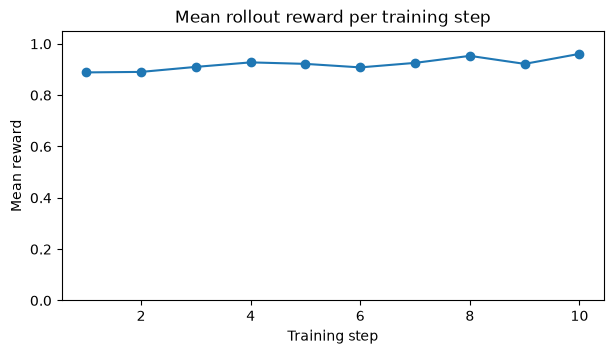

In [10]:
if job is not None and job.job_status == "Completed":
    steps = pd.DataFrame(job.get_training_metrics())
    if steps.empty:
        print("MLflow has no per-step metrics for this job yet.")
    else:
        ax = steps.plot(x="step", y="rollout/reward/mean", marker="o", legend=False, figsize=(7, 3.5))
        ax.set(title="Mean rollout reward per training step", xlabel="Training step",
               ylabel="Mean reward", ylim=(0, 1.05))
        plt.show()

## 7. Evaluation: base vs fine-tuned (official guide)

One `MultiTurnRLEvaluator(model=job, evaluate_base_model=True)` pipeline evaluates both models on the same 32 held-out tickets. Each model's metrics come from its own MLflow run.

In [11]:
evaluation = workflow.evaluation_stage()
trained_job = job if job is not None and job.job_status == "Completed" else None
execution_arn = evaluation.run_or_attach(COMPARISON_CONFIRMATION, trained_job)
status = None
if execution_arn is None:
    print("No comparison recorded yet. Set MTRL_COMPARISON_CONFIRMATION to run it.")
else:
    print("Comparison pipeline:", execution_arn)
    status = evaluation.wait(execution_arn, timeout_seconds=2 * 3600)


────────────────────────────────────────────────────────────
  MTRL Evaluation Job
────────────────────────────────────────────────────────────
  Model          : openai-reasoning-gpt-oss-20b
  Eval mode      : Base + Fine-tuned comparison
  Dataset        : s3://sagemaker-mtrl-demo-384887233198-us-west-2/datasets/evaluation_prompts.parquet
  Agent          : arn:aws:bedrock-agentcore:us-west-2:384887233198:runtime/mtrl_support_agent-OAXxBY5ULs
  Output         : s3://sagemaker-mtrl-demo-384887233198-us-west-2/comparison-evaluation/
  Region         : us-west-2
  MLflow URL     : [presigned URL removed]
────────────────────────────────────────────────────────────
  Pipeline execution started: arn:aws:sagemaker:us-west-2:384887233198:pipeline/SagemakerEvaluation-MTRLEvaluation/execution/8hvze02od4o0

Comparison pipeline: arn:aws:sagemaker:us-west-2:384887233198:pipeline/SagemakerEvaluation-MTRLEvaluation/execution/8hvze02od4o0


  04:27:01  CreateEvaluationAction: Succeeded


  04:27:01  EvaluateBaseModel: Executing


  04:28:24  EvaluateBaseModel: Succeeded


  04:28:44  EvaluateFineTunedModel: Executing


  04:30:49  EvaluateFineTunedModel: Succeeded


  04:30:49  AssociateLineage: Succeeded


Pipeline Succeeded.


,Metric,Base model,Fine-tuned model
0,Ticket fully solved (pass@1),0.578125,0.781250
1,Solved in 1 of 2 tries (pass@2),0.812500,0.937500
2,Mean reward (with partial credit),0.882812,0.925781
3,Rollouts fully solved,37.000000,50.000000
4,Rollouts not fully solved,27.000000,14.000000
5,Model calls per rollout,6.093750,6.453125


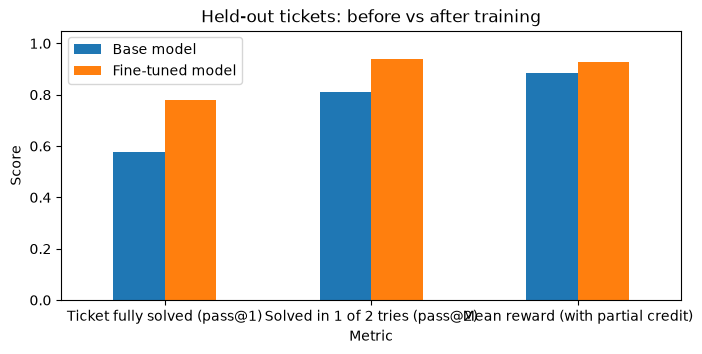

Note: 64 rollouts per model, so differences under about 0.1 are within sampling noise.


In [12]:
if status == "Succeeded":
    results = evaluation.results(execution_arn)
    comparison = pd.DataFrame([
        {"Metric": label,
         "Base model": results["base"]["metrics"].get(key),
         "Fine-tuned model": results["fine_tuned"]["metrics"].get(key)}
        for key, label in KEY_METRICS.items()
    ])
    display(comparison)
    chart = comparison.set_index("Metric").loc[[KEY_METRICS[k] for k in (
        "eval/reward/pass_at_1", "eval/reward/pass_at_2", "eval/reward/mean")]]
    ax = chart.plot.bar(figsize=(8, 3.5), rot=0, ylim=(0, 1.05))
    ax.set(title="Held-out tickets: before vs after training", ylabel="Score")
    plt.show()
    print("Note: 64 rollouts per model, so differences under about 0.1 are within sampling noise.")

## 8. Deploy and compare inference

Deployment (`ModelBuilder` → endpoint with a base inference component plus the LoRA adapter component) runs once the `ml.g6e.12xlarge` endpoint quota is approved.